# Models and campaigns

A screen ranks what you already have. This tutorial is about the other half:
predicting what you have not computed, deciding what to compute next, and
looking at the result.

The three fit together as one loop. `mv.model` fits a predictor, `mv.opt` uses
its predictions and its uncertainty to pick the next batch, and `mv.pl` shows
you what happened.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

matverse 0.1.12 — 121 functions


## Loading a dataset

Seven fcc metals at their published room-temperature lattice parameters, plus
every ordered binary between them on the L1₂ prototype — 28 materials, all of
them elements `emt` can run.

In [2]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


elemental = mv.datasets.metals()
lattice = dict(zip(elemental.obs["name"], elemental.obs["lattice_parameter"]))
symbols = list(elemental.obs["name"])

binaries = [l12(a, b, 0.5 * (lattice[a] + lattice[b]))
            for i, a in enumerate(symbols) for b in symbols[i + 1:]]

md = mv.data.from_structures(mv.structures(elemental) + binaries)
md.shape

(28, 7)

Each binary sits at the mean of its two elemental lattice parameters — a crude
guess, and deliberately so. The point of a surrogate model is to predict things
you have not relaxed.

In [3]:
mv.pp.describe(md)
mv.feat.element_stats(md)
mv.calc.energy(md, level="emt")

md.obs[["formula", "n_elements", "energy_per_atom_emt"]].head(10).round(4)

,formula,n_elements,energy_per_atom_emt
0,Al,1,-0.0016
1,Cu,1,-0.0050
2,Ni,1,-0.0076
3,Ag,1,0.0010
4,Au,1,0.0022
5,Pd,1,0.0004
6,Pt,1,-0.0001
7,Al3Cu,2,0.0904
8,Al3Ni,2,0.1805
9,Al3Ag,2,-0.0293


## The split is the part to care about

Before fitting anything, decide what "held out" means. This is not a detail — it
is the single decision that determines whether the number you report survives
contact with a material nobody has seen.

In [4]:
mv.model.split(md)          # strategy='composition' by default
md.uns["split"]

{'strategy': 'composition',
 'leaky': False,
 'n_train': 22,
 'n_test': 6,
 'seed': 0,
 'n_groups': 28,
 'n_test_groups': 6}

`mv.model.split` defaults to grouping by **composition**, and the default is the
argument. A materials dataset is full of near-duplicates — the same composition
in a different setting, the same prototype with one element swapped — so a
random split puts relatives on both sides of the line and reports a score
inflated by memorisation.

Four strategies, in rough order of how hard a test they are:

| `strategy` | What lands together | What it asks |
|---|---|---|
| `random` | nothing | almost nothing; recorded as `leaky: True` |
| `composition` | the same reduced formula | can it generalise to a new composition? |
| `prototype` | the same anonymised formula and space group | can it generalise to a new structure type? |
| `element` | everything containing a named element | can it say anything about chemistry it has never seen? |

In [5]:
mv.model.split(md, strategy="element", holdout="Ni")
md.uns["split"]["n_train"], md.uns["split"]["n_test"]

(21, 7)

The element holdout is the hardest honest split and the one a discovery campaign
actually faces. A random split never measures it.

```{note}
When you do ask for a random split, matverse records `leaky: True` in
`uns['split']` rather than refusing. A later reader can then see which kind of
number they are looking at, which is more useful than being unable to produce
it.
```

## Fitting

In [6]:
mv.model.split(md, strategy="composition")
mv.model.fit(md, target="energy_per_atom_emt")

md.uns["model"]["rf_pred"]["test_scores"]

{'n': 6,
 'mae': 0.022702394080480328,
 'rmse': 0.034759943980582804,
 'r2': 0.7533283841463639}

The prediction is a **level of theory**, not a special kind of column.

In [7]:
mv.level_info(md, "rf_pred")

{'kind': 'model',
 'method': 'random forest',
 'reference': 'emt',
 'surrogate': True,
 'license': None,
 'uncertainty': 'spread across trees (uncalibrated)',
 'trained_on': 'energy_per_atom_emt',
 'split_strategy': 'composition',
 'test_scores': {'n': 6,
  'mae': 0.022702394080480328,
  'rmse': 0.034759943980582804,
  'r2': 0.7533283841463639}}

That matters for the same reason it does everywhere else in matverse: a
predicted energy and an EMT energy cannot be averaged together by accident,
because using both means naming both. `reference: 'emt'` records that this model
was trained to reproduce EMT — so a hull built from `rf_pred` and `emt` together
is a hull of one quantity, while one mixing `rf_pred` with DFT is not.

A random forest ships an uncertainty for free, from the spread across its
trees.

In [8]:
md.obs[["formula", "energy_per_atom_emt", "energy_per_atom_emt_rf_pred",
        "energy_per_atom_emt_rf_pred_std"]].head(8).round(4)

,formula,energy_per_atom_emt,energy_per_atom_emt_rf_pred,energy_per_atom_emt_rf_pred_std
0,Al,-0.0016,0.0132,0.0486
1,Cu,-0.0050,-0.0025,0.0101
2,Ni,-0.0076,0.0010,0.0236
3,Ag,0.0010,0.0011,0.0118
4,Au,0.0022,0.0001,0.0174
5,Pd,0.0004,0.0012,0.0135
6,Pt,-0.0001,0.0005,0.0182
7,Al3Cu,0.0904,0.0777,0.0367


It is honestly labelled **uncalibrated**. It is useful for deciding what to
compute next and should not be published as an error bar without calibration.

In [9]:
mv.model.available()

{'rf': {'method': 'random forest',
  'uncertainty': 'spread across trees (uncalibrated)'},
 'ridge': {'method': 'ridge regression', 'uncertainty': None},
 'gbr': {'method': 'gradient boosting', 'uncertainty': None}}

Only scikit-learn is wired. Graph networks and fine-tuned interatomic potentials
are the real tools for large data and go behind `mv.model.register_model` rather
than being vendored — the same reasoning as `mv.calc.register_calculator`.

In [10]:
from sklearn.ensemble import ExtraTreesRegressor

mv.model.register_model("extra", ExtraTreesRegressor, method="extra trees")
mv.model.fit(md, target="energy_per_atom_emt", model="extra", level="et_pred")

md.uns["model"]["et_pred"]["test_scores"]

{'n': 6,
 'mae': 0.01621845097446179,
 'rmse': 0.02309666161300848,
 'r2': 0.8910920793698621}

## How much was the random split flattering you?

This is the function worth running before reporting any number.

In [11]:
mv.model.cross_validate(md, target="energy_per_atom_emt", seeds=(0, 1, 2))

pd.DataFrame({
    strategy: {"MAE": scores["mae"]["mean"], "±": scores["mae"]["std"]}
    for strategy, scores in md.uns["cross_validate"]["results"].items()
}).T.round(4)

,MAE,±
random,0.0309,0.0169
composition,0.0194,0.0024
prototype,0.0185,0.0000


In [12]:
md.uns["cross_validate"]["leakage_mae"]

-0.011472234372790099

`leakage_mae` is the grouped MAE minus the random one. A large **positive**
value means the random split was flattering the model — that publishing only the
random number would report a model that memorised prototypes as a model that
learned chemistry.

Here it comes out negative, and that is worth stopping on rather than glossing.
The grouped splits score *better* than random, which is not how leakage works.
Two things are going on, and both are visible in the table:

- The `±` on `prototype` is exactly **0.0000**. This library has two structure
  types — elemental fcc and L1₂ binary — so there is essentially one way to
  partition it by prototype, and three seeds produce three identical splits. A
  diagnostic that cannot vary is not measuring anything.
- The `±` on `random` is **larger than the gap between any two rows**. With a
  six-material test set the seed-to-seed noise swamps the effect the comparison
  exists to detect.

So the honest reading of this table is *"this dataset is too small and too
homogeneous to run the diagnostic"*, not *"there is no leakage"*. Run it on a
few thousand materials with real structural diversity and the ordering in the
original design note — random flattering, prototype punishing — is what appears.

```{warning}
Three seeds is the minimum here, and the spread is why. A single seed moved one
cell of a published benchmark panel by ten points; the `±` column is what stops
you reading noise as a result — including, as above, reading it as a result
about leakage.
```

## Deciding what to compute next

A campaign is a loop, not a pipeline, and it needs somewhere to record rounds.
It works on a **pool**: the candidates are all in the object, a few are known,
most are not, and each round picks a batch.

That shape is right for materials. The search space is a list of structures, not
a box of real numbers, so this is pool-based active learning rather than
continuous optimisation.

In [13]:
truth = md.obs["energy_per_atom_emt"].to_numpy(dtype=float).copy()

seeded = np.full(md.n_obs, np.nan)
seeded[:6] = truth[:6]                    # pretend only six have been computed
md.obs["objective"] = seeded

mv.opt.start(md, objective="objective", goal="min")
md.obs["observed"].sum()

np.int64(6)

Each round: fit on what is known, ask for a batch, "compute" it, fold it back.

In [14]:
for _ in range(4):
    md.obs["split"] = np.where(md.obs["observed"], "train", "test")
    mv.model.fit(md, target="objective", level="pred")

    mv.opt.suggest(md, n=3, method="ucb",
                   predicted="objective_pred",
                   uncertainty="objective_pred_std")

    picked = np.where(md.obs["selected"])[0]
    mv.opt.observe(md, values={str(md.obs_names[i]): truth[i] for i in picked})

mv.opt.history(md)

,round,n_selected,n_observed,best_so_far,method,n_requested,beta,diversify,predicted,uncertainty
0,1,3,9,-0.032842,ucb,3,1.0,False,objective_pred,objective_pred_std
1,2,3,12,-0.059849,ucb,3,1.0,False,objective_pred,objective_pred_std
2,3,3,15,-0.059849,ucb,3,1.0,False,objective_pred,objective_pred_std
3,4,3,18,-0.059849,ucb,3,1.0,False,objective_pred,objective_pred_std


In [15]:
round(float(truth.min()), 6), round(float(md.obs["objective"].min()), 6)

(-0.059849, -0.059849)

The campaign found the true optimum having computed a fraction of the
twenty-eight candidates. That is the entire point: compute is the binding
constraint in materials discovery, so which few you pick is the problem.

### Acquisition functions

| `method` | Picks | When |
|---|---|---|
| `greedy` | the best predicted | you trust the model and want the answer now |
| `uncertainty` | the least known | you are building a training set, not optimising |
| `ucb` | mean plus `beta` × sigma | the general-purpose default |
| `ei` | expected improvement over the best seen | late in a campaign, when gains are small |
| `random` | anything | the baseline a campaign has to beat, and often does not |

```{warning}
`uncertainty`, `ucb` and `ei` **refuse** when no uncertainty column exists,
rather than treating sigma as zero. A UCB run with sigma silently zero is a
greedy run wearing a different name, and it will report the same number while
exploring nothing.
```

In [16]:
try:
    mv.opt.suggest(md, n=3, method="ucb", predicted="objective_pred",
                   uncertainty="not_a_column")
except (KeyError, ValueError) as exc:
    print(f"{type(exc).__name__}: {exc}")

ValueError: uncertainty='not_a_column' is not an obs column. Available: ['energy_per_atom_emt_et_pred_std', 'energy_per_atom_emt_rf_pred_std', 'objective_pred_std']. An acquisition that needs sigma refuses rather than treating it as zero, because that would be a greedy run under another name.


### Diversifying a batch

The ten highest-scoring candidates are often ten variations on one idea, and
computing all ten answers one question rather than ten.

In [17]:
mv.pp.normalize_composition(md)
mv.tl.pca(md, n_comps=3)

mv.opt.suggest(md, n=5, method="ucb", diversify=True, use_rep="X_pca",
               predicted="objective_pred", uncertainty="objective_pred_std")

list(md.obs["formula"][md.obs["selected"]])

['Al3Cu', 'Cu3Ag', 'Ni3Ag', 'Ag3Pd', 'PtAu3']

Farthest-point selection among a shortlist, so the batch spreads out in
descriptor space instead of clustering.

### Random as the control

Worth running once. A campaign that does not beat random selection is not
learning, and the only way to know is to try.

```python
mv.opt.suggest(md, n=3, method='random', predicted='objective_pred')
```

## Looking at it

Every plotting function draws onto an axis and returns it, and none calls
`plt.show()` — a library that shows figures cannot be used to build one.

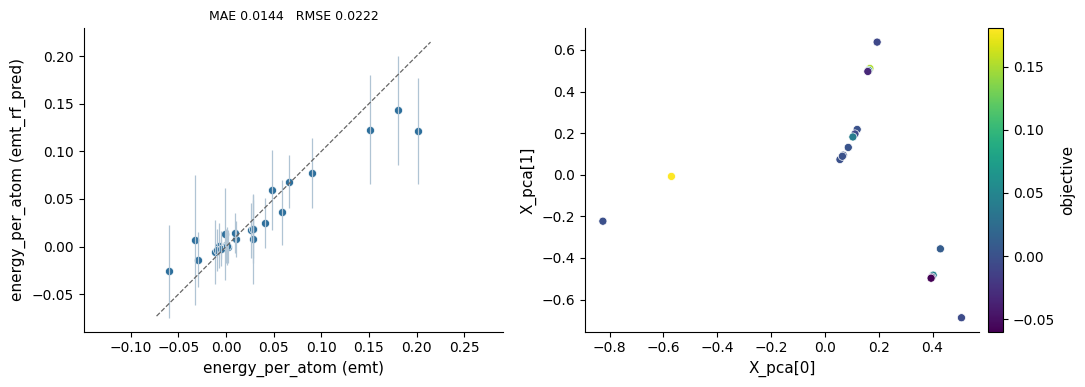

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mv.pl.parity(md, "energy_per_atom", "emt", "emt_rf_pred", ax=axes[0])
mv.pl.embedding(md, color="objective", ax=axes[1])
fig.tight_layout()

`mv.pl.parity` draws the error bars when an uncertainty column exists,
annotates MAE and RMSE, and — this is the useful bit — prints a warning **on the
plot** if the two levels reproduce different methods. A parity plot silently
comparing PBE against r2SCAN looks exactly like one comparing PBE against PBE.

### The periodic table

The natural display for element-level results, in the way a dot plot is the
natural display for differential expression.

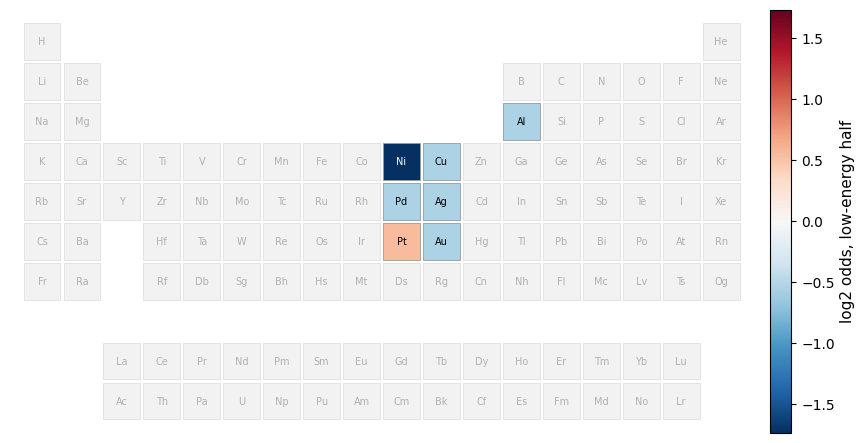

In [19]:
md.obs["low_energy"] = (md.obs["energy_per_atom_emt"]
                        <= md.obs["energy_per_atom_emt"].median())
mv.tl.rank_elements_groups(md, "low_energy")

frame = md.uns["rank_elements_groups"]["True"]
scores = frame.set_index("element")["log2_odds"].reindex(md.var_names)

ax = mv.pl.periodic_table(md, values=scores.to_numpy(),
                          label="log2 odds, low-energy half", center=0.0)

A bar chart of 118 categories is unreadable and throws away the structure a
chemist reads a periodic table for — groups above one another, periods across.
`center=0.0` makes the diverging colour map symmetric about no enrichment.

Text(0.5, 1.0, 'the same result, ranked')

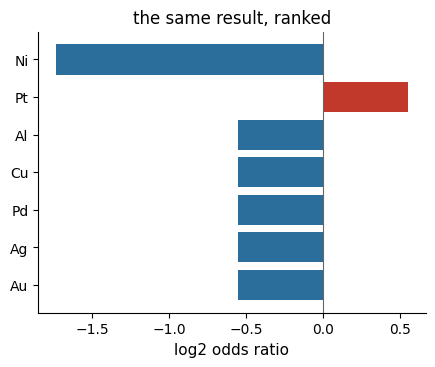

In [20]:
ax = mv.pl.rank_elements_groups(md, group="True", n=10)
ax.set_title("the same result, ranked")

### The rest

```python
mv.pl.hull(md, level='emt', x='Al')       # labels itself if the hull is closed
mv.pl.pareto(md, 'e_above_hull_emt', 'density')
mv.pl.spectra(md, 'xrd', rows=[0, 1, 2], offset=30)
```

`mv.pl.provenance` draws the operation history as a figure. It is taken from the
object rather than from a lab notebook, which is the reason for recording
provenance in the object at all.

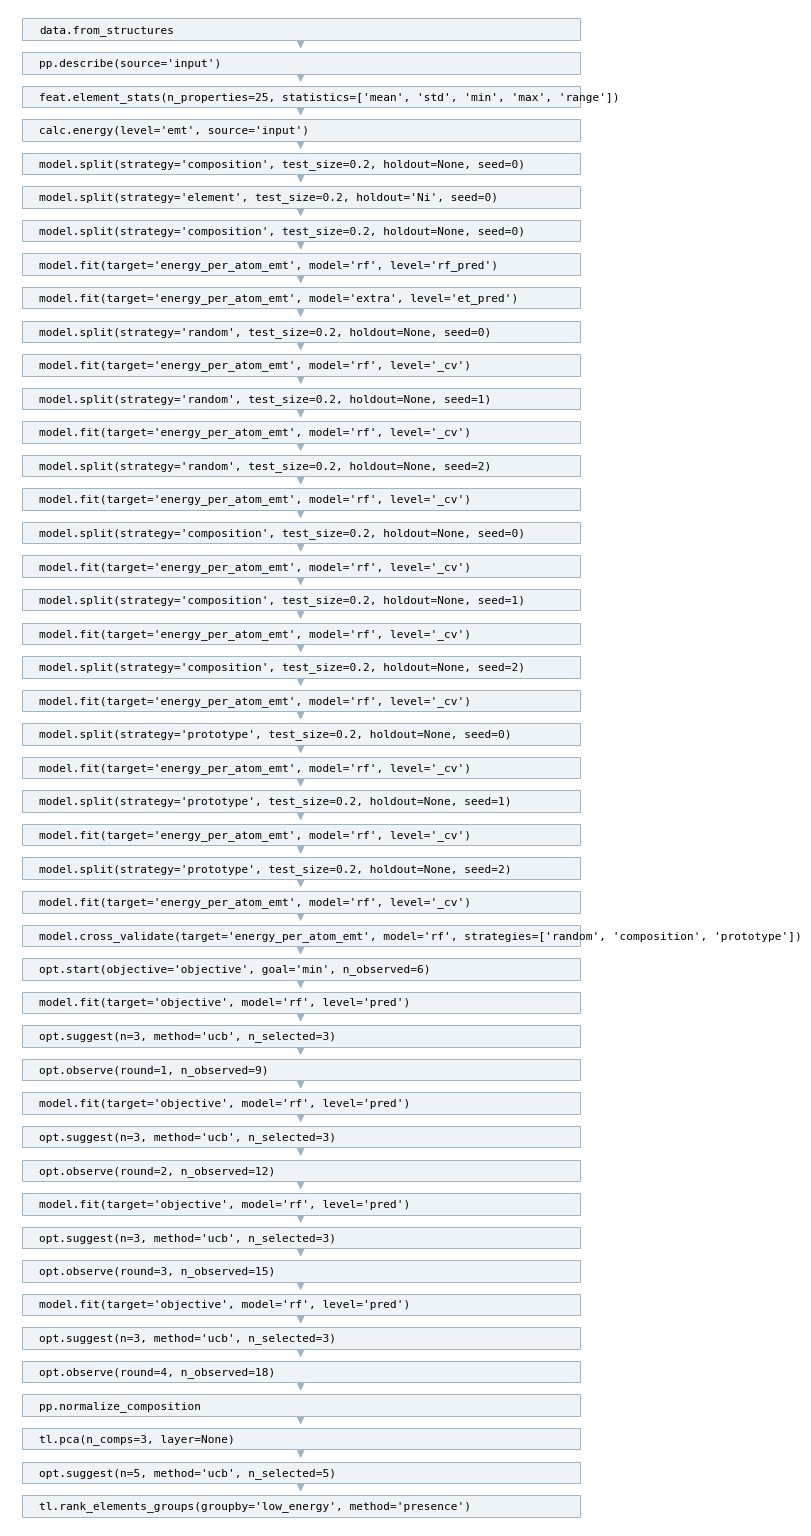

In [21]:
ax = mv.pl.provenance(md)

```{note}
matplotlib is an optional dependency (`pip install "matverse[plot]"`), imported
inside each plotting function. Producing a number and drawing it are different
jobs, and a screening pipeline on a cluster should not need a plotting stack to
run.
```

```{seealso}
[Scale and first principles](scale_and_dft.md) covers the other direction: what
to do when the candidate list is larger than memory, and how to hand the
survivors to DFT.
```